In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import dataframe_image as dfi
from scipy.stats import pearsonr
from itertools import combinations

**Load all the data from the CSV file into a pandas data frame, saved in a variable called df.**

In [2]:
df = pd.read_csv("proteinbase_all_data.csv")
df

,id,name,sequence,author,designMethod,evaluations
0,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,"[{""type"":""computational"",""value"":""Not Assigned..."
1,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":true,""metric"":..."
2,violet-ram-dust,1.3.3.18_4149_15,SPETDTINGLAKCPEEYIHFCIHGVCKFIQEQETPSCRCNKGYNGSRCE,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":true,""metric"":..."
3,dark-orca-crystal,1.3.3.18_1221_0,SNTVERCPSAHDTYCLYGGVCFYIPELQQYACNCVPGYVGERCQYS...,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":false,""metric""..."
4,soft-raven-frost,1.3.3.18_1409_17,SGPLRSPEPATDFPGRGLPCPVDHYCLNGGRCKFLEELQEYACECV...,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":true,""metric"":..."
...,...,...,...,...,...,...
1045,violet-moth-crystal,GPLSKAEYLEEQIKFVEENKDKKELVKPKLIETLKYVGYDEEAEYY...,GPLSKAEYLEEQIKFVEENKDKKELVKPKLIETLKYVGYDEEAEYY...,escalante-bio,mosaic,"[{""type"":""experimental"",""value"":true,""metric"":..."
1046,steady-bat-crystal,EVNCELLNKLAEPVAKELFPENDLAKISTFYAALFFAYEGALKGKP...,EVNCELLNKLAEPVAKELFPENDLAKISTFYAALFFAYEGALKGKP...,escalante-bio,mosaic,"[{""type"":""experimental"",""value"":true,""metric"":..."
1047,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,"[{""type"":""experimental"",""value"":true,""metric"":..."
1048,green-raven-ember,PD-L1,WQAYNKGMYVDKFRAEIVRFHHDQNPYMYIIWQWLVHVPPKVVKRR...,NaN,NaN,"[{""type"":""computational"",""value"":""Not Assigned..."


**Explode the evaluations column out so that each metric within the evaluations column is represented in rows.**

In [3]:
import json

df["evaluations"] = df["evaluations"].apply(json.loads)

# print(type(alldata.loc[0, "evaluations"]))

df_metrics = df.explode("evaluations", ignore_index=True)
df_metrics = df_metrics.join(pd.json_normalize(df_metrics.pop("evaluations")))
df_metrics

,id,name,sequence,author,designMethod,type,value,metric,valueType,unit,value.url,target
0,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,Not Assigned,design_class,label,NaN,NaN,NaN
1,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,25259.3216,molecular_weight,numeric,Da,NaN,NaN
2,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,5.340501,isoelectric_point,numeric,pH,NaN,NaN
3,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,57.84548,esmfold_plddt,numeric,%,NaN,NaN
4,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,Eeeeee,foldstring,label,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
45946,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,2.7348,proteinmpnn_score,numeric,NaN,NaN,NaN
45947,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,1.42608,redesigned_proteinmpnn_score,numeric,NaN,NaN,NaN
45948,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,0.16866,proteinmpnn_seq_recovery,numeric,%,NaN,NaN
45949,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,NaN,esmfold_structure_prediction,json,NaN,https://proteinbase-pub.t3.storage.dev/01K6MZG...,NaN


**Filter out the cases where there's no design method.**

In [4]:
df_filtered = df_metrics.dropna(subset=["designMethod"])
df_filtered

,id,name,sequence,author,designMethod,type,value,metric,valueType,unit,value.url,target
49,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,True,expressed,boolean,NaN,NaN,NaN
50,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,True,binding,boolean,NaN,NaN,egfr
51,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,Medium,binding_strength,label,NaN,NaN,egfr
52,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,0.0,kd,numeric,M,NaN,egfr
53,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,37550.788416,kon,numeric,M,NaN,egfr
...,...,...,...,...,...,...,...,...,...,...,...,...
45888,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,1.2829,proteinmpnn_score,numeric,NaN,NaN,NaN
45889,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,0.86607,redesigned_proteinmpnn_score,numeric,NaN,NaN,NaN
45890,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,0.63625,proteinmpnn_seq_recovery,numeric,%,NaN,NaN
45891,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,NaN,esmfold_structure_prediction,json,NaN,https://proteinbase-pub.t3.storage.dev/01K6J32...,NaN


**Drop the irrelevant columns. Make a generalized function and call it.**

In [5]:
def drop_columns(df, columns):
    """
    Drop the specified columns from a pandas dataframe.
    """
    return df.drop(columns=columns, axis=1, errors='ignore')

columns_to_drop = ['author', 'value.url', 'name']
df_filtered = drop_columns(df_filtered, columns_to_drop)
df_filtered["id"].nunique()

489

**Get a quick overview over how many unique binders per design method**

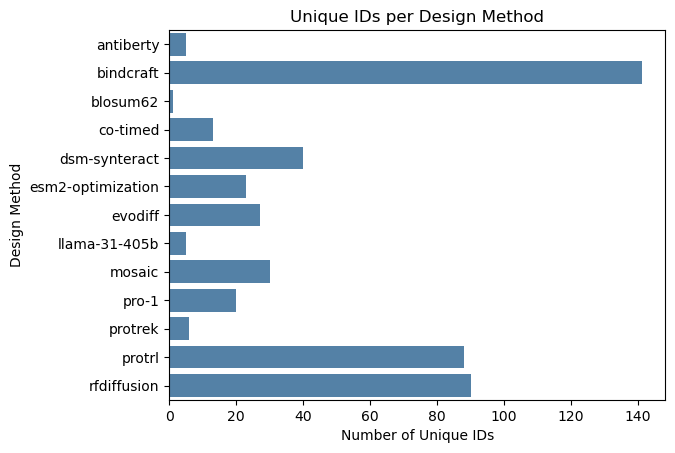

,designMethod,unique_id_count
0,antiberty,5
1,bindcraft,141
2,blosum62,1
3,co-timed,13
4,dsm-synteract,40
5,esm2-optimization,23
6,evodiff,27
7,llama-31-405b,5
8,mosaic,30
9,pro-1,20


In [6]:
unique_ids_per_design_method = df_filtered.groupby('designMethod')['id'].nunique().reset_index()
unique_ids_per_design_method.rename(columns={'id': 'unique_id_count'}, inplace=True)

sns.barplot(data=unique_ids_per_design_method, x="unique_id_count", y="designMethod", color="steelblue")
plt.xlabel("Number of Unique IDs")
plt.ylabel("Design Method")
plt.title("Unique IDs per Design Method")
plt.show()

unique_ids_per_design_method

**Print out the unique metrics to have an overview, and decide which metrics we want to look at.**

In [7]:
print(df_filtered["metric"].unique())
df_filtered["metric"].value_counts()


['expressed' 'binding' 'binding_strength' 'kd' 'kon' 'koff'
 'bli_kinetic_curves' 'design_class' 'molecular_weight'
 'isoelectric_point' 'esmfold_plddt' 'foldstring' 'classification'
 'ted_confidence' 'seqidentityafdb50' 'evalueafdb50' 'tm-scoreafdb50'
 'rmsdafdb50' 'aligned-lengthafdb50' 'cath_detail' 'seqidentitycath50'
 'evaluecath50' 'tm-scorecath50' 'rmsdcath50' 'aligned-lengthcath50'
 'seqidentitypdb100' 'evaluepdb100' 'tm-scorepdb100' 'rmsdpdb100'
 'aligned-lengthpdb100' 'proteinmpnn_score' 'redesigned_proteinmpnn_score'
 'proteinmpnn_seq_recovery' 'esmfold_structure_prediction'
 'esmfold_stylized_image' 'boltz2_plddt' 'boltz2_ptm' 'boltz2_iptm'
 'boltz2_complex_plddt' 'boltz2_complex_iplddt' 'boltz2_complex_pde'
 'boltz2_pdockq' 'boltz2_pdockq2' 'boltz2_lis' 'interface_residues']


metric
expressed                       1264
bli_kinetic_curves              1263
binding                         1261
binding_strength                1261
esmfold_plddt                   1130
foldstring                       630
classification                   630
ted_confidence                   630
rmsdcath50                       614
evaluecath50                     614
cath_detail                      614
seqidentitycath50                614
aligned-lengthcath50             614
tm-scorecath50                   614
aligned-lengthafdb50             613
rmsdafdb50                       613
tm-scoreafdb50                   613
evalueafdb50                     613
seqidentityafdb50                613
seqidentitypdb100                610
evaluepdb100                     610
aligned-lengthpdb100             610
rmsdpdb100                       610
tm-scorepdb100                   610
proteinmpnn_score                500
molecular_weight                 500
design_class                   

**Create a function that takes a list of metrics as an argument and filter them into a new data frame. This is done to choose which metrics to look at in the subsequent analysis, to make a more coherent focus.**
**To change the metrics you want to see, simply edit the 'relevant_metrics' list.**

In [8]:
def filter_by_metrics(df, relevant_metrics, metric_column="metric"):
    """
    Filter a data frame to only include rows where the metric column matches one of the specified relevant metrics.
    relevant_metrics is a list of the metrics you want to inspect.
    Default value for the metric column is set, but can be modified if it has another name in another data set.
    """

    return df[df[metric_column].isin(relevant_metrics)].copy()

relevant_metrics = ['esmfold_plddt', 'proteinmpnn_score', 'expressed', 'binding', 'binding_strength', 'rmsdafdb50', 'rmsdcath50', 'rmsdpdb100', 'tm-scorecath50', 'tm-scoreafdb50', 'tm-scorepdb100', 'seqidentityafdb50', 'seqidentitycath50', 'seqidentitypdb100', 'redsigned_proteinmpnn_score']

df_filtered_by_metrics = filter_by_metrics(df_filtered, relevant_metrics)
df_filtered_by_metrics

,id,sequence,designMethod,type,value,metric,valueType,unit,target
49,jade-otter-jade,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,protrl,experimental,True,expressed,boolean,NaN,NaN
50,jade-otter-jade,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,protrl,experimental,True,binding,boolean,NaN,egfr
51,jade-otter-jade,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,protrl,experimental,Medium,binding_strength,label,NaN,egfr
56,jade-otter-jade,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,protrl,experimental,True,expressed,boolean,NaN,NaN
57,jade-otter-jade,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,protrl,experimental,True,binding,boolean,NaN,egfr
...,...,...,...,...,...,...,...,...,...
45882,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,mosaic,computational,21.3,seqidentitypdb100,numeric,%,NaN
45884,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,mosaic,computational,0.5956,tm-scorepdb100,numeric,%,NaN
45885,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,mosaic,computational,2.87,rmsdpdb100,numeric,Å,NaN
45887,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,mosaic,computational,85.574233,esmfold_plddt,numeric,%,NaN


**Due to each ID having several values per metric (because there have been several studies on the same binders), the next step is to compile each binder's metric values in a single row.**

In [9]:
metric_cols = ["value", "valueType", "unit", "sequence"]

df_agg = df_filtered_by_metrics.groupby(["id", "metric"]).agg({"value": lambda x: list(x), "valueType": lambda x: list(x), "unit": lambda x: list(x), "target": lambda x: list(set(x)), "designMethod": lambda x: list(set(x)), "type": lambda x: list(set(x)), "sequence": lambda x: list(set(x))}).reset_index()

df_agg

,id,metric,value,valueType,unit,target,designMethod,type,sequence
0,amber-bear-ice,binding,"[False, False]","[boolean, boolean]","[nan, nan]",[egfr],[bindcraft],[experimental],[SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLA...
1,amber-bear-ice,binding_strength,"[None, None]","[label, label]","[nan, nan]",[egfr],[bindcraft],[experimental],[SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLA...
2,amber-bear-ice,esmfold_plddt,"[86.40138783269967, 86.3354844778928]","[numeric, numeric]","[%, %]",[nan],[bindcraft],[computational],[SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLA...
3,amber-bear-ice,expressed,"[True, True]","[boolean, boolean]","[nan, nan]",[nan],[bindcraft],[experimental],[SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLA...
4,amber-bear-ice,proteinmpnn_score,[0.9897],[numeric],[nan],[nan],[bindcraft],[computational],[SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLA...
...,...,...,...,...,...,...,...,...,...
6628,young-quail-leaf,seqidentitycath50,[28.2],[numeric],[%],[nan],[bindcraft],[computational],[NPEIKKLHEEYHELQWKFWAEMSKAFDAGDDKKIEELVEENVKRT...
6629,young-quail-leaf,seqidentitypdb100,[21.8],[numeric],[%],[nan],[bindcraft],[computational],[NPEIKKLHEEYHELQWKFWAEMSKAFDAGDDKKIEELVEENVKRT...
6630,young-quail-leaf,tm-scoreafdb50,[0.86985],[numeric],[%],[nan],[bindcraft],[computational],[NPEIKKLHEEYHELQWKFWAEMSKAFDAGDDKKIEELVEENVKRT...
6631,young-quail-leaf,tm-scorecath50,[0.62982],[numeric],[%],[nan],[bindcraft],[computational],[NPEIKKLHEEYHELQWKFWAEMSKAFDAGDDKKIEELVEENVKRT...


**After the explosion several rows will show NaN in the target column, which needs to be fixed so that each row has a value in the target cell (as the target will always be the same for each ID / sequence / binder. There was only one row pr. ID / sequence / binder before, but now due to the explosion there's several rows pr. ID).**

In [10]:
# Function to extract a non-nan value from a list
def extract_valid_target(lst):
    if not isinstance(lst, list):
        return np.nan
    values = [x for x in lst if pd.notna(x)]
    return values[0] if values else np.nan

# Creating a new helper column with a single representative target value per row
df_agg["target_clean"] = df_agg["target"].apply(extract_valid_target)

# Fill

df_agg["target_clean"] = (df_agg.groupby("id")["target_clean"].transform(lambda x: x.ffill().bfill()))

# Replace the orignial column with the clean one
df_agg["target"] = df_agg["target_clean"].apply(lambda x: [x] if pd.notna(x) else [np.nan])
df_agg.drop(columns="target_clean", inplace=True)

df_agg

,id,metric,value,valueType,unit,target,designMethod,type,sequence
0,amber-bear-ice,binding,"[False, False]","[boolean, boolean]","[nan, nan]",[egfr],[bindcraft],[experimental],[SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLA...
1,amber-bear-ice,binding_strength,"[None, None]","[label, label]","[nan, nan]",[egfr],[bindcraft],[experimental],[SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLA...
2,amber-bear-ice,esmfold_plddt,"[86.40138783269967, 86.3354844778928]","[numeric, numeric]","[%, %]",[egfr],[bindcraft],[computational],[SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLA...
3,amber-bear-ice,expressed,"[True, True]","[boolean, boolean]","[nan, nan]",[egfr],[bindcraft],[experimental],[SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLA...
4,amber-bear-ice,proteinmpnn_score,[0.9897],[numeric],[nan],[egfr],[bindcraft],[computational],[SAVDAAAAVFAAKPAEELDRYKILAGSALDYMKHAIRTGLPRQLA...
...,...,...,...,...,...,...,...,...,...
6628,young-quail-leaf,seqidentitycath50,[28.2],[numeric],[%],[egfr],[bindcraft],[computational],[NPEIKKLHEEYHELQWKFWAEMSKAFDAGDDKKIEELVEENVKRT...
6629,young-quail-leaf,seqidentitypdb100,[21.8],[numeric],[%],[egfr],[bindcraft],[computational],[NPEIKKLHEEYHELQWKFWAEMSKAFDAGDDKKIEELVEENVKRT...
6630,young-quail-leaf,tm-scoreafdb50,[0.86985],[numeric],[%],[egfr],[bindcraft],[computational],[NPEIKKLHEEYHELQWKFWAEMSKAFDAGDDKKIEELVEENVKRT...
6631,young-quail-leaf,tm-scorecath50,[0.62982],[numeric],[%],[egfr],[bindcraft],[computational],[NPEIKKLHEEYHELQWKFWAEMSKAFDAGDDKKIEELVEENVKRT...


**Now we need to exclude the proteins / binders which where not expressed at all.**

In [11]:
# Keep only the expressed metric
expressed_data = df_agg[df_agg["metric"] == "expressed"].copy()

# Define a function to check if all values in the list are False
def all_false(values):
    if not isinstance(values, list) or len(values) == 0:
        return False
    clean_vals = [v for v in values if pd.notna(v)]
    return all(v is False for v in clean_vals)

# Apply the function to mark which ID's have all False in expressed
expressed_data["all_false"] = expressed_data["value"].apply(all_false)

# Get the ID's to remove
id_to_remove = expressed_data.loc[expressed_data["all_false"], "id"].unique()

# Filter original df

df_filtered_expressed = df_agg[~df_agg["id"].isin(id_to_remove)].copy()

# For future use when going through this or other data sets, a reusable filtering function. Note that this function expects the column name to be "metric" and the value column to be named "value".
# Also uses the previously defined all_false function, so compile these two together.
# This function can remove all the "false" values if needed.

def remove_all_false(df, metric_name):
    temp = df[df["metric"] == metric_name].copy()
    temp["all_false"] = temp["value"].apply(all_false)
    bad_ids = temp.loc[temp["all_false"], "id"].unique()
    return df[~df["id"].isin(bad_ids)].copy()

df_filtered_expressed["id"].nunique()

470

**Having a dataframe where each metric pr. ID is gathered in lists might be relevant for some analysis which is why I made it in the first place.**
**It also helped in terms of filtering out the ones which weren't expressed as it gathered those values.**

**Next step is to prepare the new data frame for analysis. That requires us to flatten our lists into strings, so that seaborn and matplotlib can work with it.**
**This is kind of reversing one of the earlier steps, but the earlier steps are important for the overview of the data.**

In [12]:
# First I use a for loop to flatten the non value columns to not interfere with the analysis.

list_columns = ["valueType", "unit", "target", "designMethod", "type", "sequence"]

df_copy = df_filtered_expressed.copy()

for col in list_columns:
    if col in df_copy.columns:
        df_copy[col] = df_copy[col].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)

# Then I define a function that flattens the value column, which is helpful as I want to transfer the individual values into their own row again. It also keeps the binding_strength value by making it into a string if we want to analyze that.

def normalize_list_values(x):
    if not isinstance(x, list):
        return [x]
    normalized = []
    for v in x:
        if v is None or (isinstance(v, float) and pd.isna(v)):
            normalized.append(None)
        elif isinstance(v, (int, float, bool)):
            normalized.append(v)
        else:
            normalized.append(str(v))
    return normalized

df_copy["value_single"] = df_copy["value"].apply(normalize_list_values)

# explode to make one value per row (only if value_list actually contains list)
df_copy = df_copy.explode("value_single", ignore_index=True)

# Sort for clarity

df_copy = df_copy.sort_values(by=["metric", "designMethod"])

df_copy = df_copy.drop(columns=["value"])

df_copy.rename(columns={"value_single": "values"}, inplace=True)

df_copy


,id,metric,valueType,unit,target,designMethod,type,sequence,values
1404,brisk-vole-quartz,binding,boolean,NaN,egfr,antiberty,experimental,EVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,True
1405,brisk-vole-quartz,binding,boolean,NaN,egfr,antiberty,experimental,EVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,True
1406,brisk-vole-quartz,binding,boolean,NaN,egfr,antiberty,experimental,EVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,True
2653,gentle-fox-rose,binding,boolean,NaN,egfr,antiberty,experimental,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,True
2654,gentle-fox-rose,binding,boolean,NaN,egfr,antiberty,experimental,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,True
...,...,...,...,...,...,...,...,...,...
10034,violet-shark-birch,tm-scorepdb100,numeric,%,egfr,rfdiffusion,computational,AECPEEYKNYCKHGTCLYDVKKNKPVCLCDKGYLGPRCEKKDLSLLL,0.32867
10136,violet-zebra-pearl,tm-scorepdb100,numeric,%,egfr,rfdiffusion,computational,QYYVVKLKFESPDGTEKTVVLRGPDYKTVLKAASDLTLDKASEGWR...,0.48694
10166,wild-crane-rose,tm-scorepdb100,numeric,%,il7r,rfdiffusion,computational,SEAEKAAEKAREALKKAKEARKKFEEAAKKLAEKRPELKEDMEEAI...,0.27136
10208,wild-lion-snow,tm-scorepdb100,numeric,%,egfr,rfdiffusion,computational,SDAQDIANIYLENIEKLLERRGWEEEKEKVRKELEEAVKNKSVDEV...,0.5964


**First step is to summarize % binders per design method**

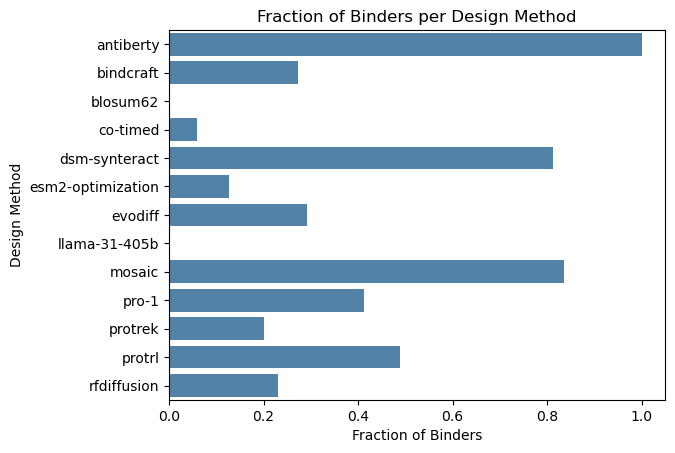

,designMethod,binding_status
0,antiberty,1.0
1,bindcraft,0.273038
2,blosum62,0.0
3,co-timed,0.058824
4,dsm-synteract,0.8125
5,esm2-optimization,0.127273
6,evodiff,0.290909
7,llama-31-405b,0.0
8,mosaic,0.835443
9,pro-1,0.411765


In [13]:
binding_info = (df_copy[df_copy["metric"] == "binding"][["designMethod", "values"]].rename(columns={"values": "binding_status"}))

binder_ratio = (binding_info.groupby("designMethod")["binding_status"].mean().reset_index()) # proportion of True values

sns.barplot(data=binder_ratio, x="binding_status", y="designMethod", color="steelblue")
plt.xlabel("Fraction of Binders")
plt.ylabel("Design Method")
plt.title("Fraction of Binders per Design Method")
plt.show()

binder_ratio

**I also want to see if all the targets are the same for the individual design methods, or if they vary.**

In [14]:
target_counts = (df_copy.groupby("designMethod").agg(unique_targets = ('target', 'nunique'), targets_list = ('target', lambda x: ", ".join(sorted(x.dropna().unique())))).reset_index().sort_values("unique_targets", ascending=False))

unique_binders = df_copy.drop_duplicates(subset=["id", "designMethod", "target"]).copy()

cross_tab = pd.crosstab(unique_binders["designMethod"], unique_binders["target"])

target_counts

,designMethod,unique_targets,targets_list
1,bindcraft,5,"der21, der7, egfr, ifnar2, spcas9"
4,dsm-synteract,2,"egfr, pd-l1"
8,mosaic,2,"il7r, pd-l1"
12,rfdiffusion,2,"egfr, il7r"
0,antiberty,1,egfr
3,co-timed,1,egfr
2,blosum62,1,egfr
6,evodiff,1,mdm2
5,esm2-optimization,1,egfr
7,llama-31-405b,1,egfr


**The next step is to make boxplots of the metrics of interest chosen earlier. This step should be customizable so that it will update when updating the relevant_metrics list further up.**

**These plots don't group into binders / non binders but rather just take both categories into consideration. The fraction of binders per design method is shown in above barplot.**

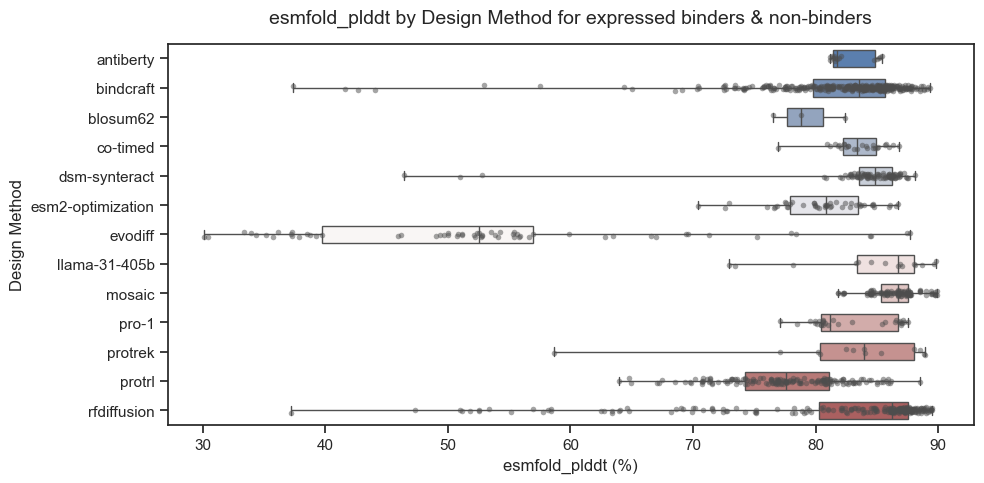

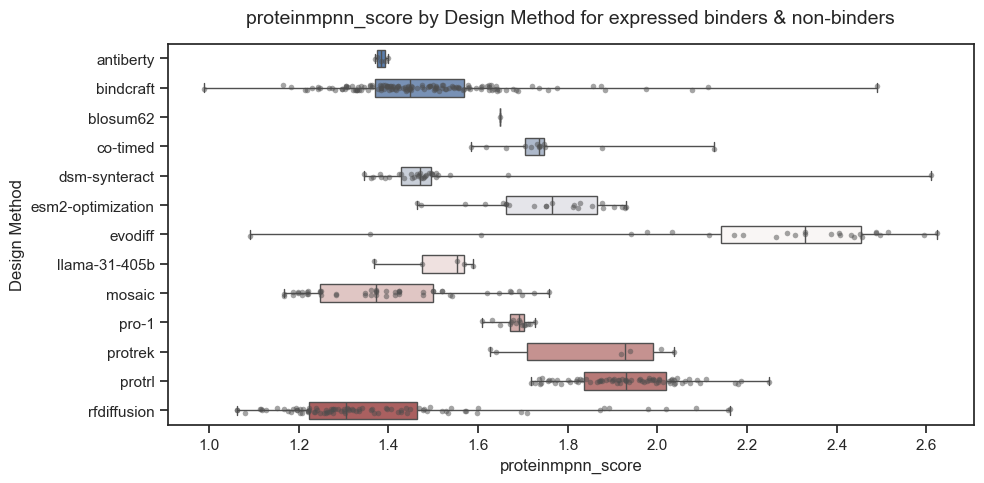

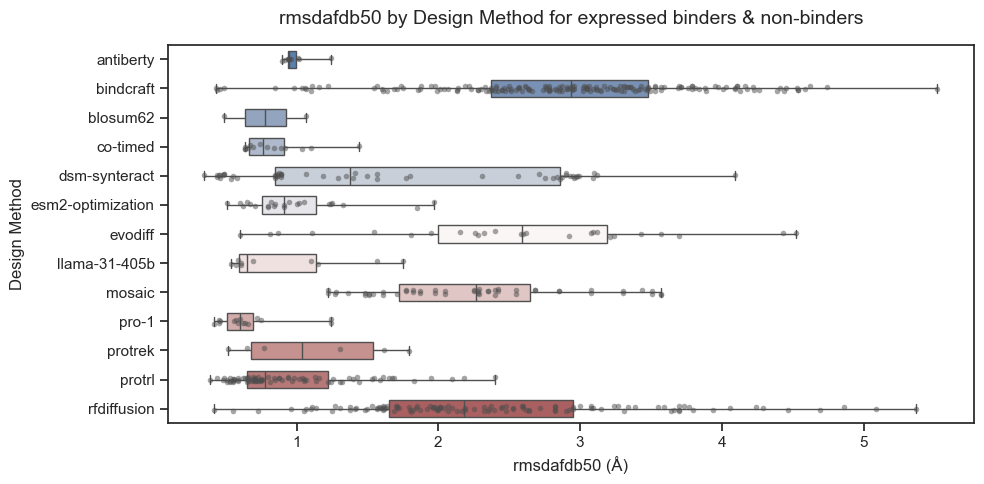

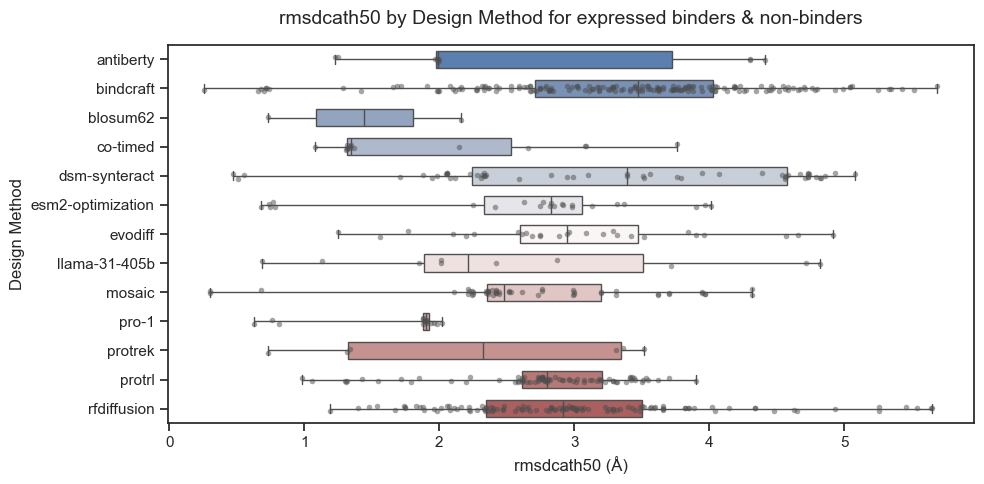

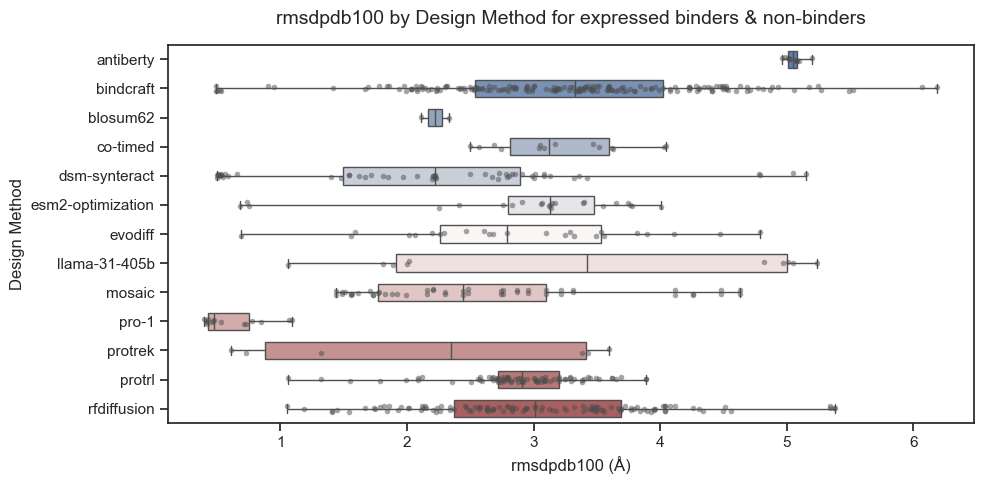

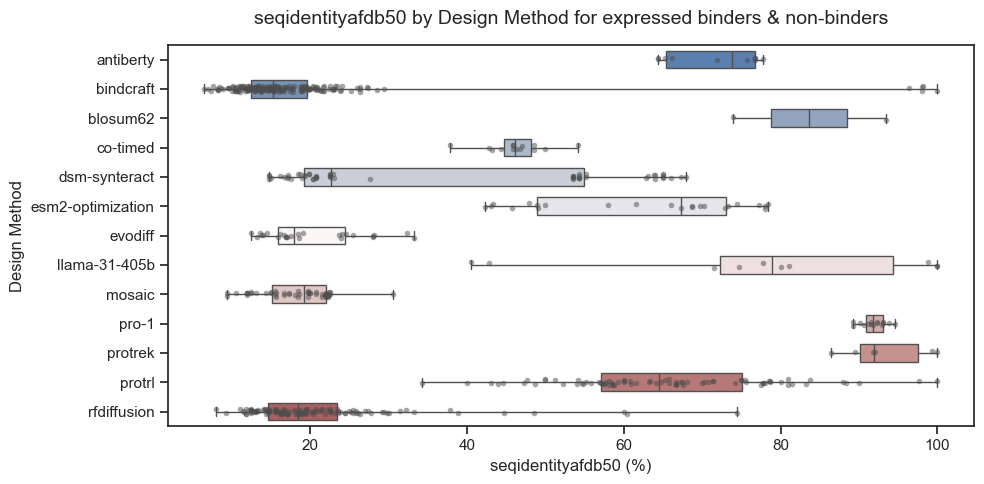

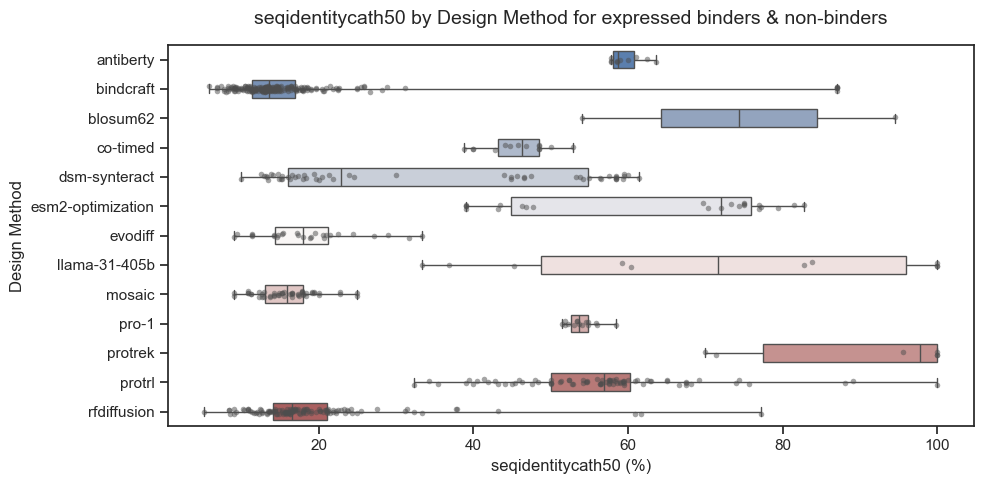

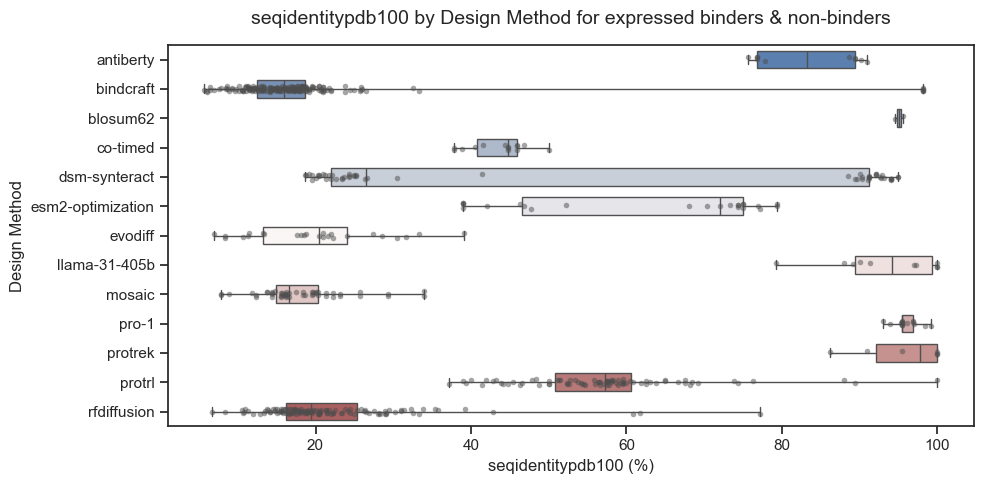

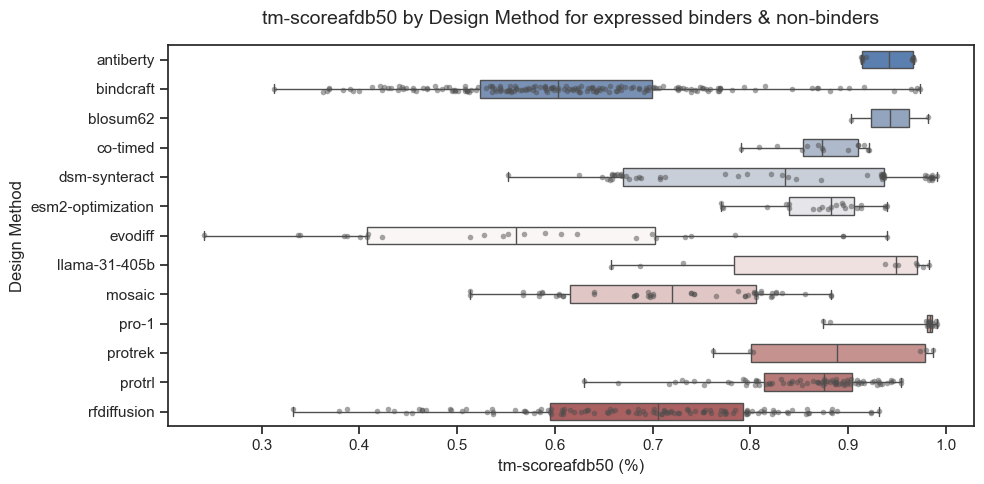

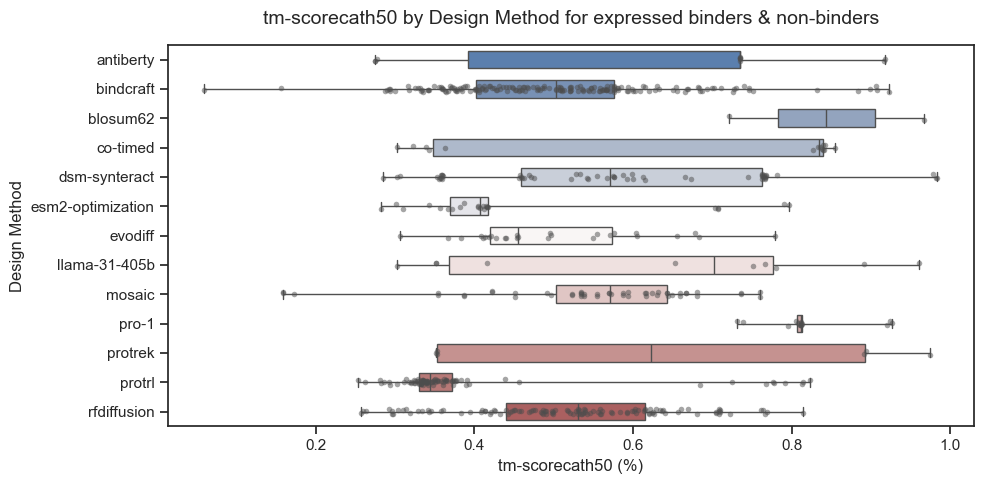

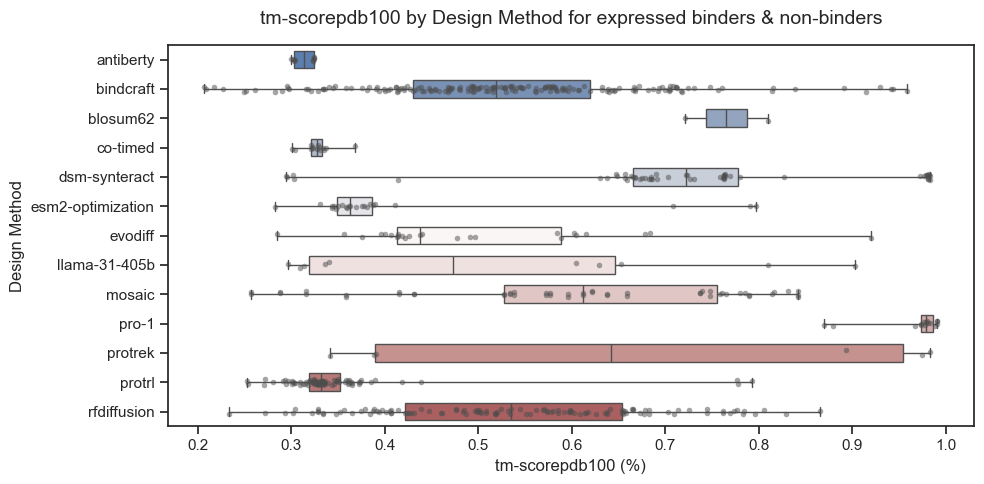

In [15]:
# First we need to filter for the numeric values. If we want to use the boolean values such as binding or the label values from binding strength (medium, None) we can just change "numeric" into either boolean or label and then further change our way of analyzing down the code.

numeric_df = df_copy[df_copy["valueType"] == "numeric"]

# Then we get the unique metrics

metrics = numeric_df["metric"].dropna().unique()
sns.set_theme(style="ticks", font_scale=1)

for m in metrics:
    subset = numeric_df[numeric_df["metric"] == m]

    unit = subset["unit"].dropna().unique()
    unit_label = f" ({unit[0]})" if len(unit) > 0 else ""

    plt.figure(figsize=(10, 5))
    ax = sns.boxplot(data=subset, y="designMethod", x="values", hue="designMethod", whis=[0, 100], orient="h", width=0.6, palette="vlag", fliersize=3, legend=False)

    sns.stripplot(data=subset, y="designMethod", x="values", orient="h", color=".3", size=4, alpha=0.5, jitter=True)

    ax.set_title(f"{m} by Design Method for expressed binders & non-binders", fontsize=14, pad=15)
    ax.set_xlabel(f"{m}{unit_label}")
    ax.set_ylabel("Design Method")
    
    plt.tight_layout()
    plt.show()


**I will now collide the two plots so that the colour hue of the horizontal box plots will be equivalent to the % of binders.**

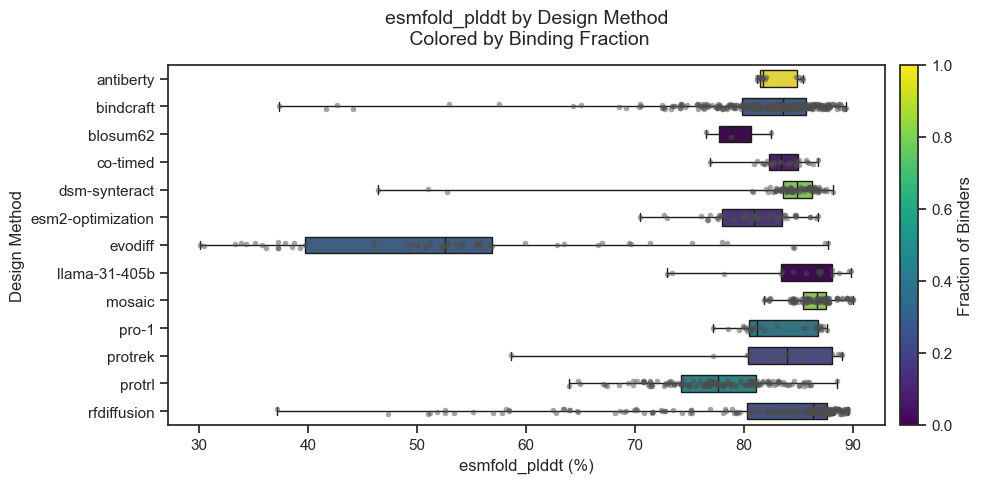

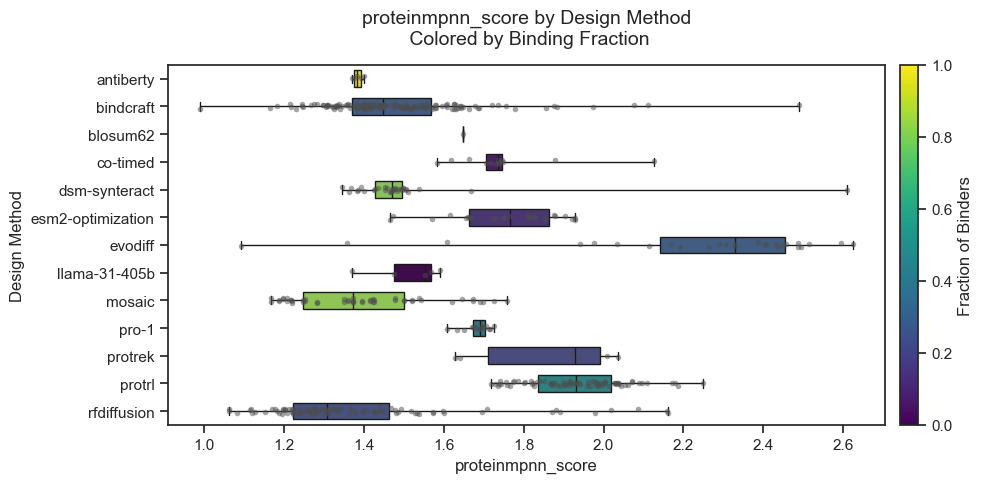

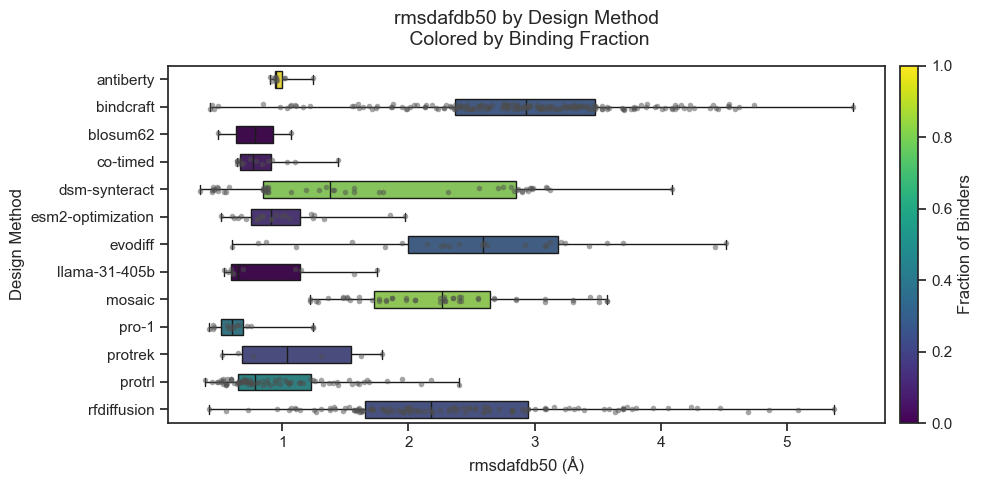

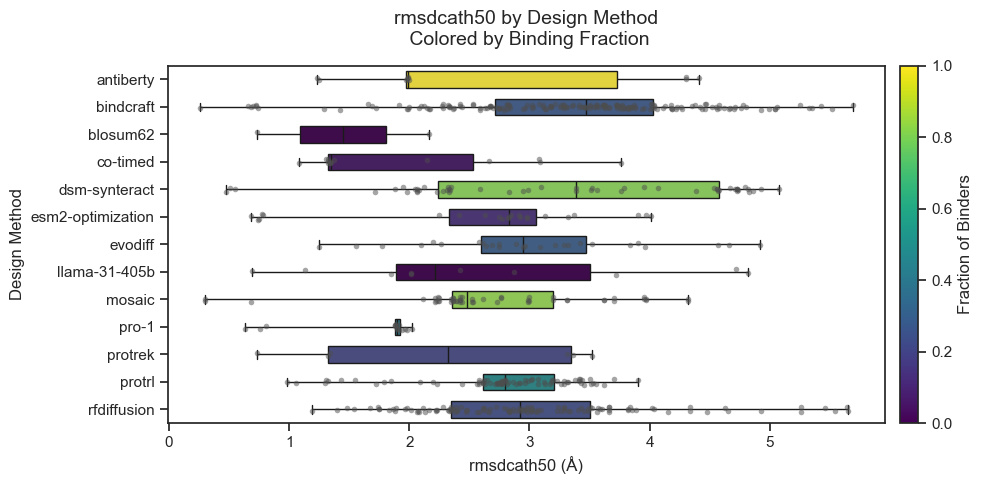

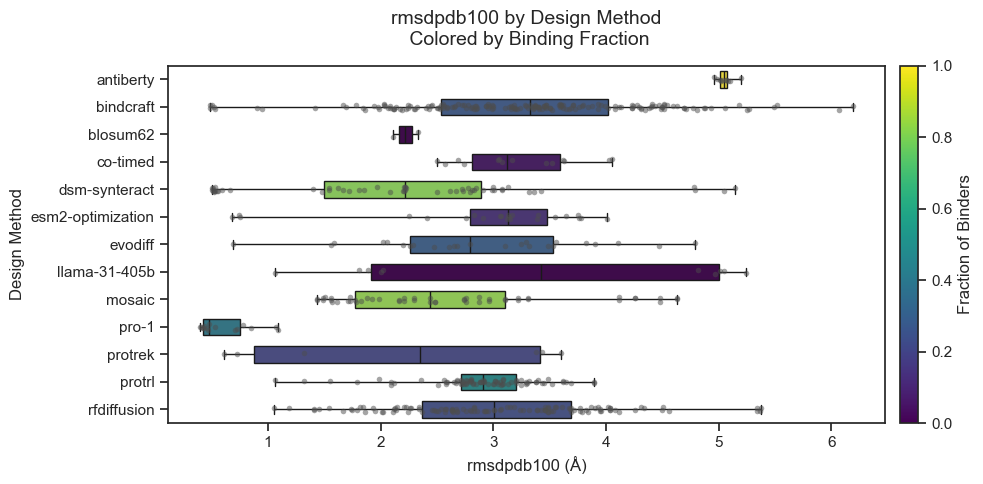

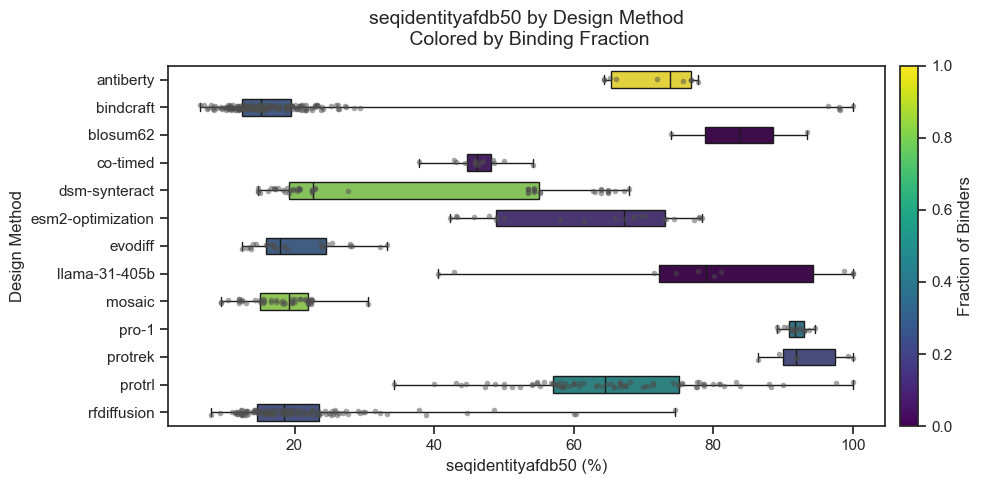

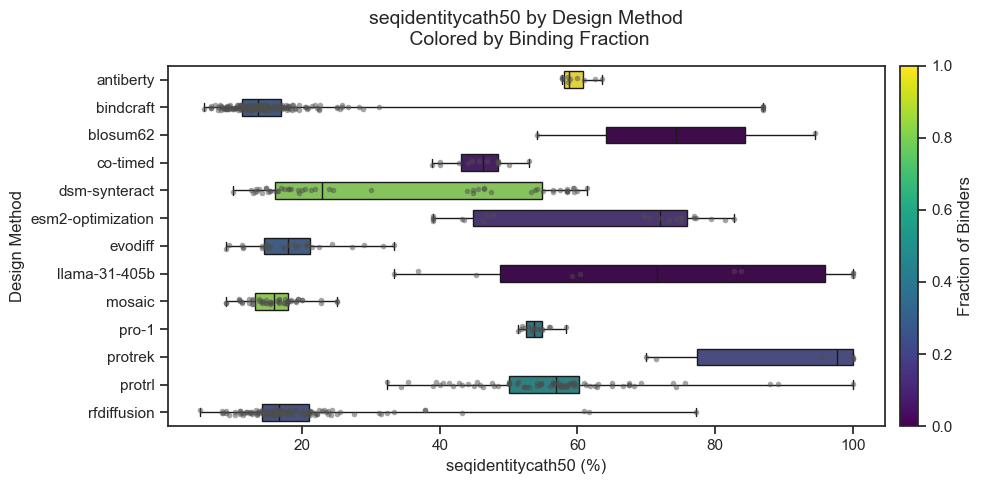

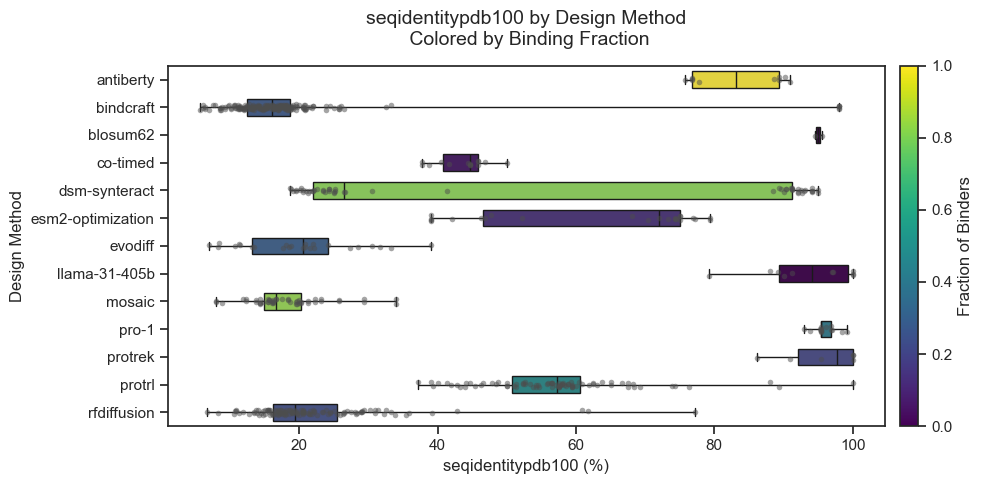

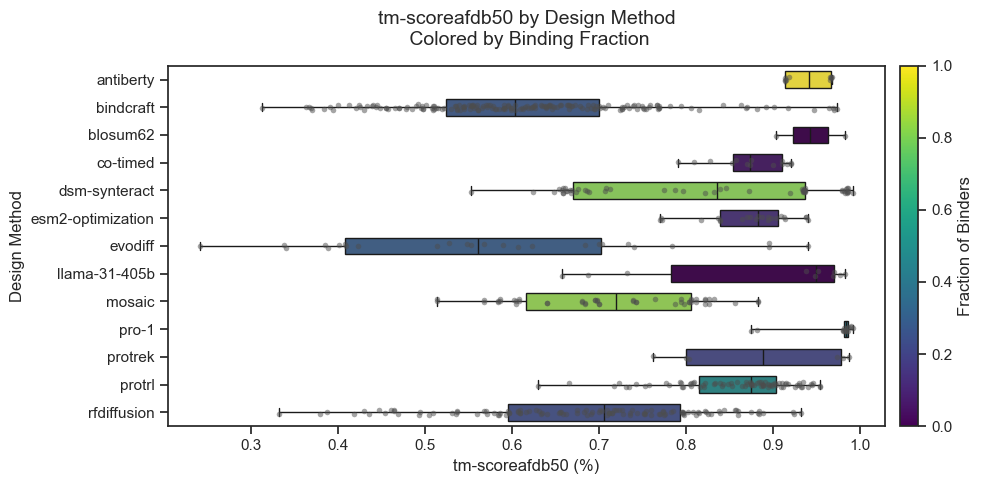

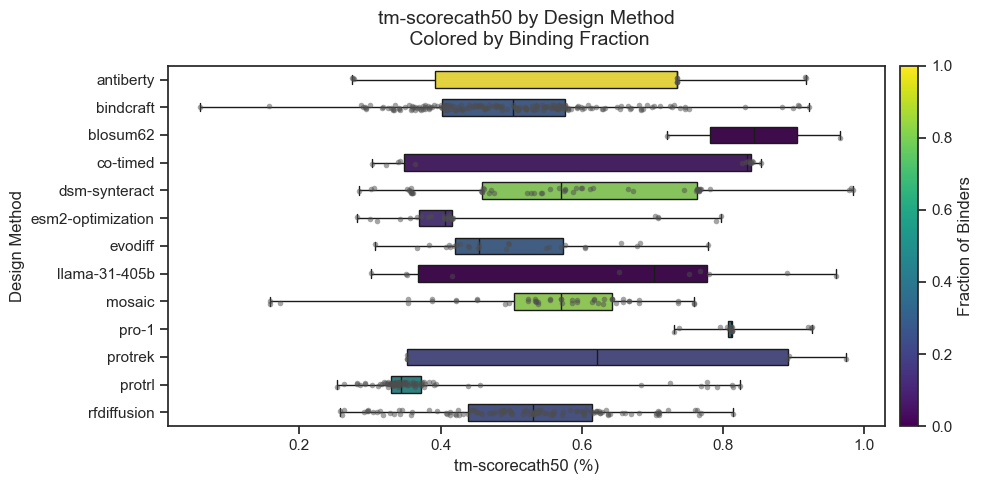

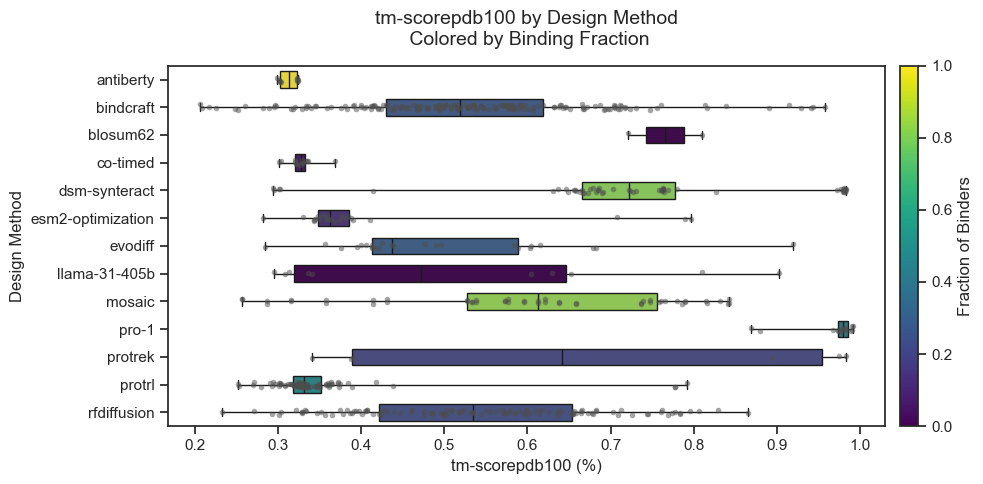

In [16]:
numeric_df = numeric_df.merge(binder_ratio, on="designMethod", how="left")

cmap = sns.color_palette("viridis", as_cmap=True)
metrics = numeric_df["metric"].dropna().unique()
sns.set_theme(style="ticks", font_scale=1)

for m in metrics:
    subset = numeric_df[numeric_df["metric"] == m].copy()

    unit = subset["unit"].dropna().unique()
    unit_label = f" ({unit[0]})" if len(unit) > 0 else ""

    design_methods = subset["designMethod"].unique()
    ratios = subset.drop_duplicates("designMethod").set_index("designMethod")["binding_status"]

    palette = {dm: cmap(ratios.loc[dm]) for dm in design_methods}
    plt.figure(figsize=(10, 5))

    ax = sns.boxplot(data=subset, y="designMethod", x="values", hue="designMethod", whis=[0, 100], orient="h", width=0.6, palette=palette, fliersize=3, legend=False)

    sns.stripplot(data=subset, y="designMethod", x="values", orient="h", color=".3", size=4, alpha=0.5, jitter=True)

    ax.set_title(f"{m} by Design Method\n Colored by Binding Fraction", fontsize= 14, pad=15)
    ax.set_xlabel(f"{m}{unit_label}")
    ax.set_ylabel("Design Method")

    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar( sm, ax=ax, orientation='vertical' , fraction=0.03, pad=0.02)
    cbar.set_label('Fraction of Binders')
    

    plt.tight_layout()
    plt.show()

**I also want to try to divide binders and non-binders so that the data can be further analyzed in respect to whether it's binders or not.**

In [17]:
binding_df = df_copy[df_copy["metric"] =="binding"].copy()

binders = binding_df.loc[binding_df["values"] == True, "id"].unique()
non_binders = binding_df.loc[binding_df["values"] == False, "id"].unique()

df_binders = df_copy[df_copy["id"].isin(binders)].copy()
df_non_binders = df_copy[df_copy["id"].isin(non_binders)].copy()
df_binders
 


,id,metric,valueType,unit,target,designMethod,type,sequence,values
1404,brisk-vole-quartz,binding,boolean,NaN,egfr,antiberty,experimental,EVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,True
1405,brisk-vole-quartz,binding,boolean,NaN,egfr,antiberty,experimental,EVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,True
1406,brisk-vole-quartz,binding,boolean,NaN,egfr,antiberty,experimental,EVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,True
2653,gentle-fox-rose,binding,boolean,NaN,egfr,antiberty,experimental,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,True
2654,gentle-fox-rose,binding,boolean,NaN,egfr,antiberty,experimental,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,True
...,...,...,...,...,...,...,...,...,...
9012,steady-swan-onyx,tm-scorepdb100,numeric,%,il7r,rfdiffusion,computational,MELLKKAEEAVELVKEVAEKLDKETARILFLTAVDQGAAPVLRAAA...,0.55558
9569,swift-panda-snow,tm-scorepdb100,numeric,%,il7r,rfdiffusion,computational,EVLEKAKELYEKAKELIEEAKKLAEEGNFEEAEKKIEEVRELVLEL...,0.32203
9693,vast-ant-crystal,tm-scorepdb100,numeric,%,il7r,rfdiffusion,computational,EDKKEAEEALEEAEKAKKELEKALKELAELDPSLKEEAEEMIKVAE...,0.62573
10166,wild-crane-rose,tm-scorepdb100,numeric,%,il7r,rfdiffusion,computational,SEAEKAAEKAREALKKAKEARKKFEEAAKKLAEKRPELKEDMEEAI...,0.27136


**This is horizontal box plots for binders only.**

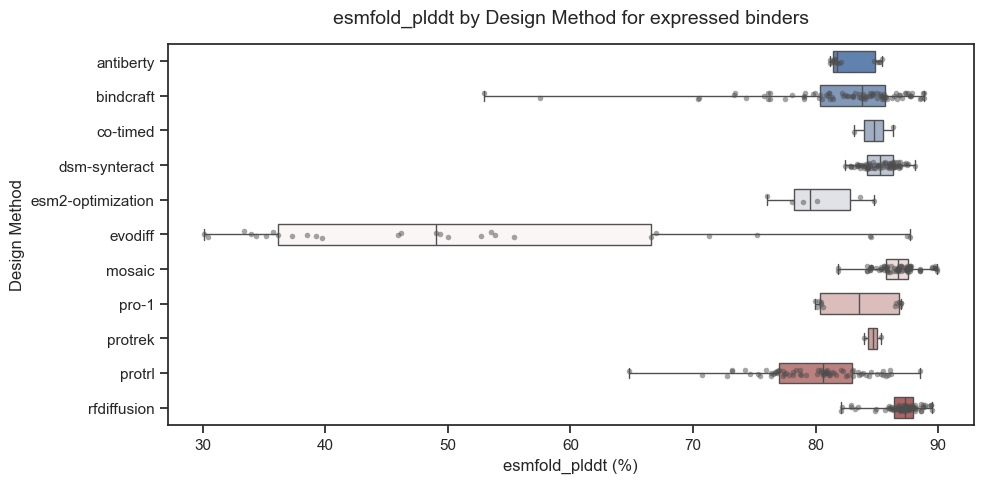

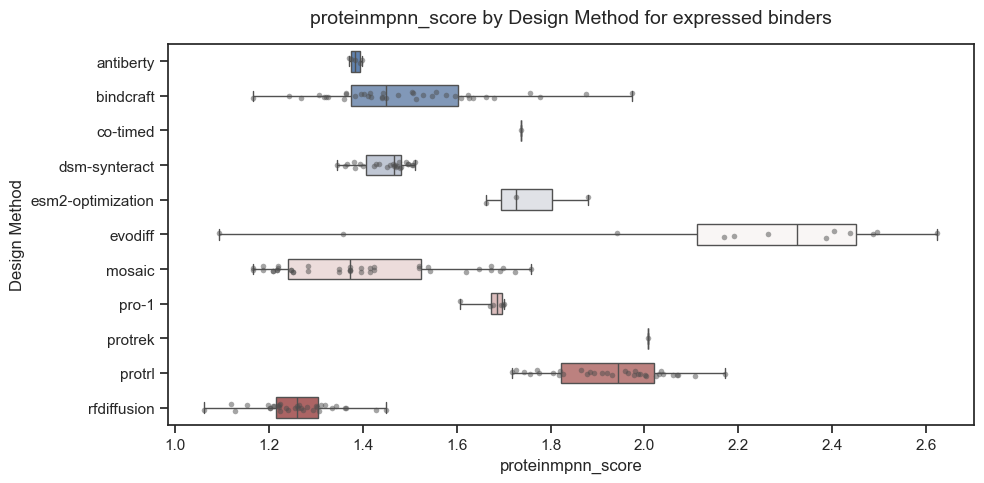

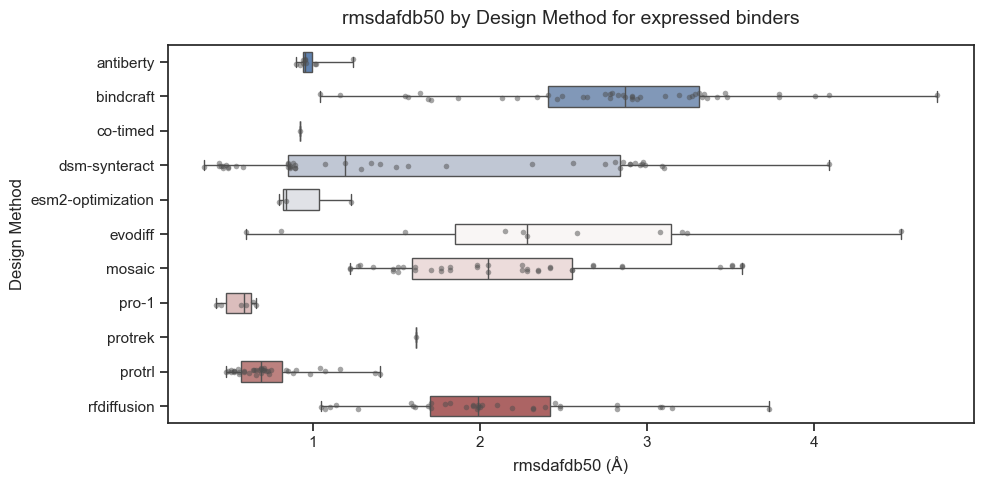

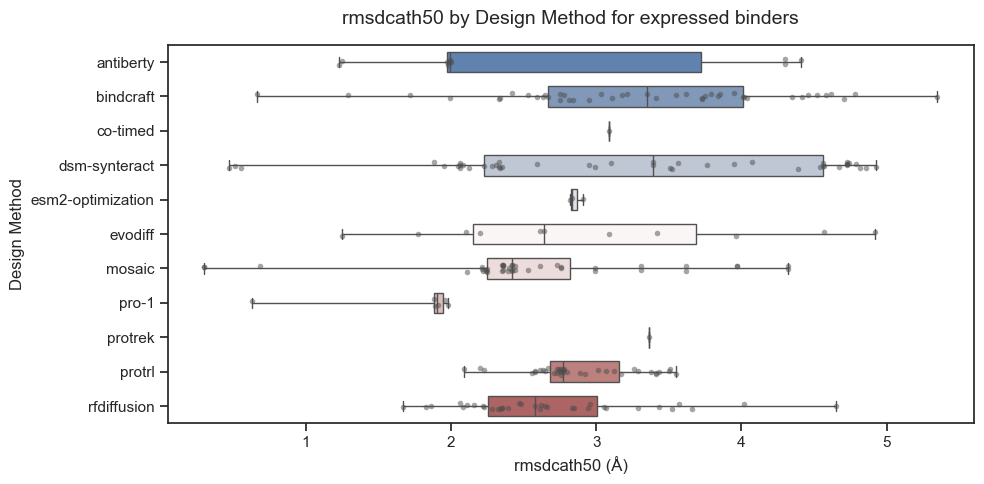

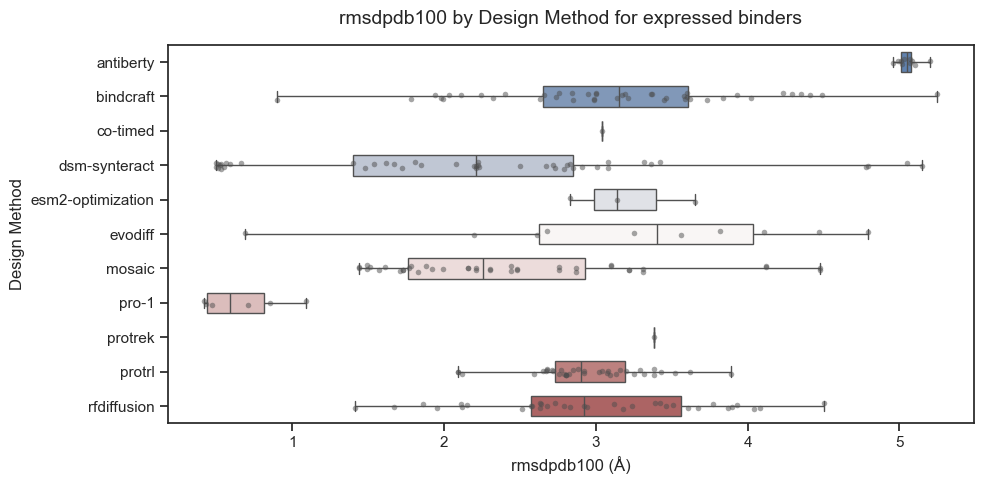

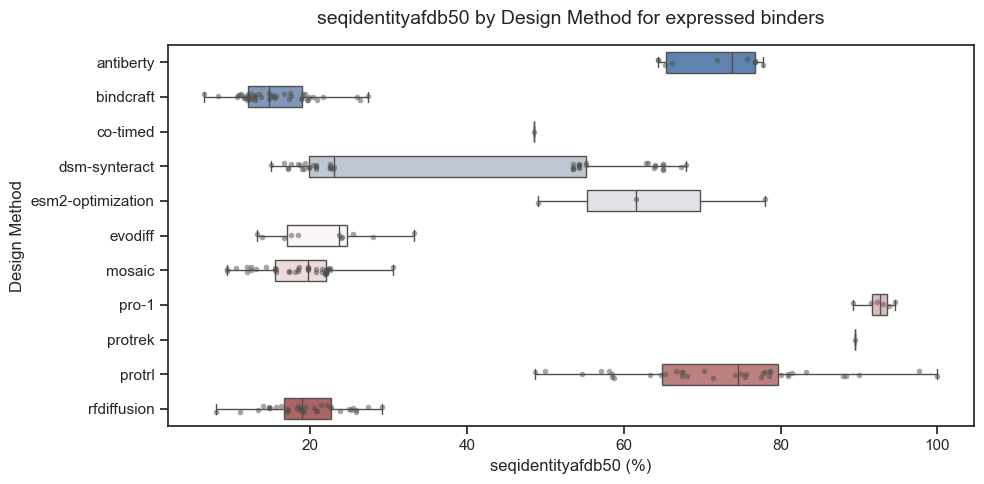

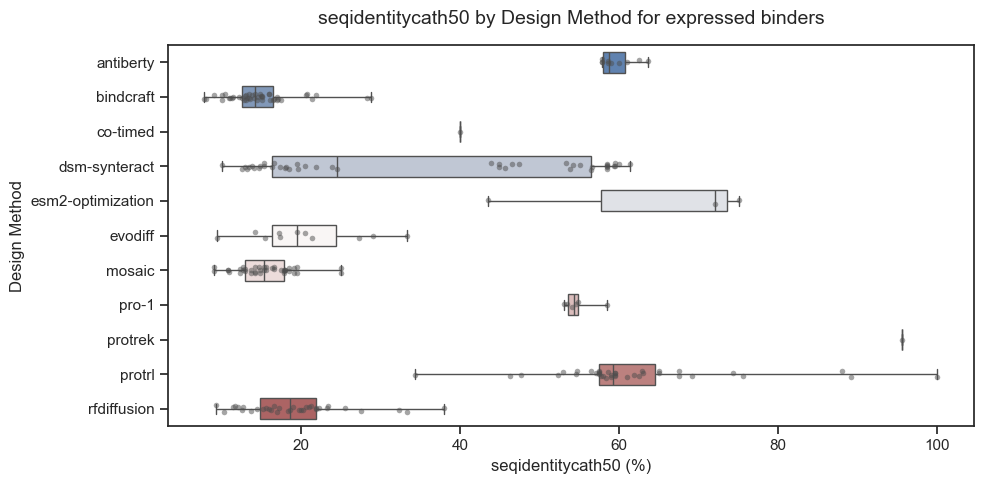

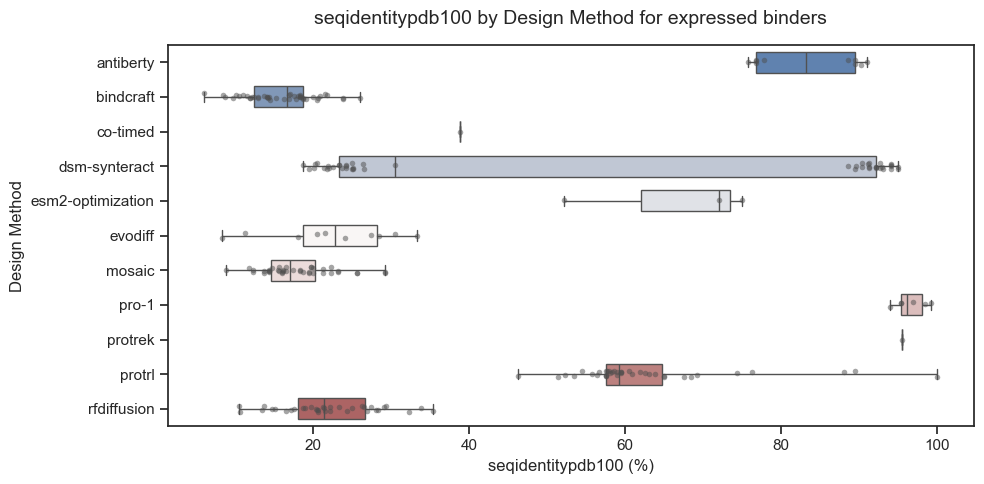

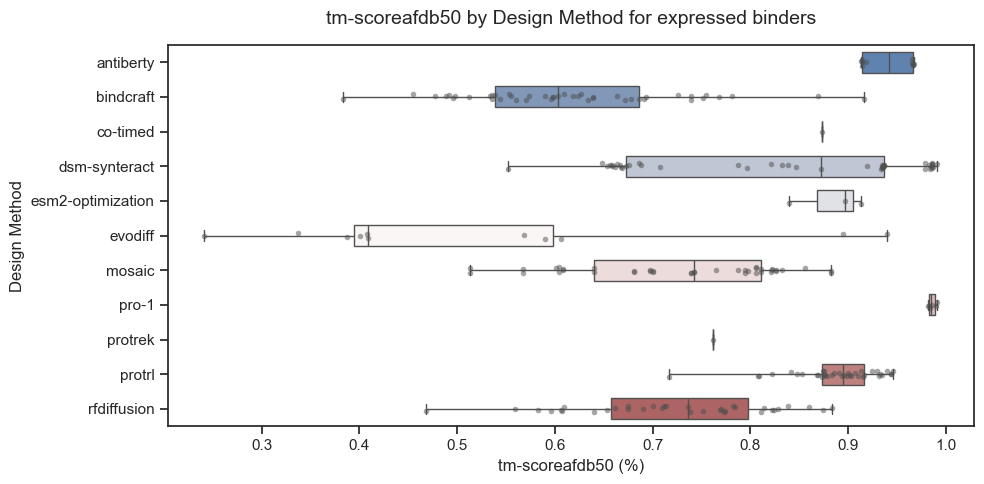

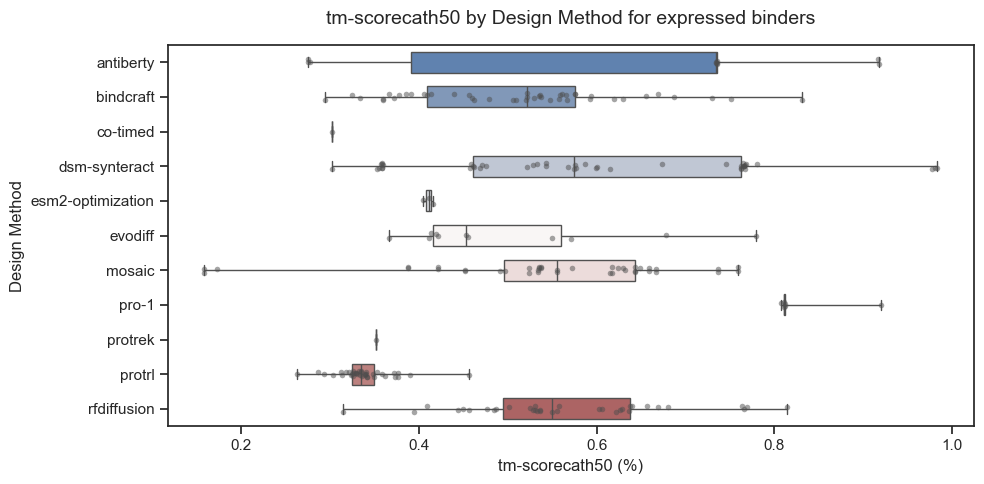

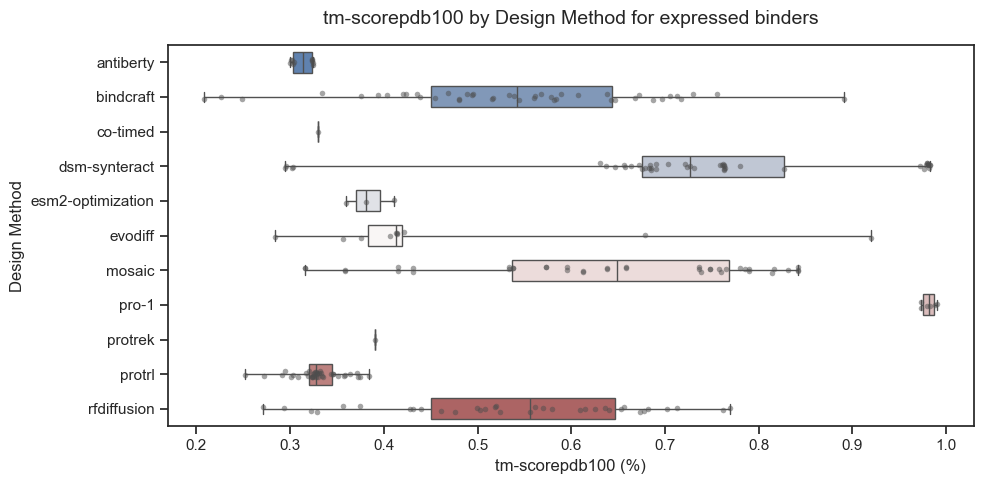

In [18]:
# First we need to filter for the numeric values. If we want to use the boolean values such as binding or the label values from binding strength (medium, None) we can just change "numeric" into either boolean or label and then further change our way of analyzing down the code.

numeric_df_binders = df_binders[df_binders["valueType"] == "numeric"]

# Then we get the unique metrics

metrics = numeric_df_binders["metric"].dropna().unique()
sns.set_theme(style="ticks", font_scale=1)

for m in metrics:
    subset = numeric_df_binders[numeric_df_binders["metric"] == m]

    unit = subset["unit"].dropna().unique()
    unit_label = f" ({unit[0]})" if len(unit) > 0 else ""

    plt.figure(figsize=(10, 5))
    ax = sns.boxplot(data=subset, y="designMethod", x="values", hue="designMethod", whis=[0, 100], orient="h", width=0.6, palette="vlag", fliersize=3, legend=False)

    sns.stripplot(data=subset, y="designMethod", x="values", orient="h", color=".3", size=4, alpha=0.5, jitter=True)

    ax.set_title(f"{m} by Design Method for expressed binders", fontsize=14, pad=15)
    ax.set_xlabel(f"{m}{unit_label}")
    ax.set_ylabel("Design Method")
    
    plt.tight_layout()
    plt.show()

**Now I want to compare the design methods in regards to the binding strength shown for the binders.**

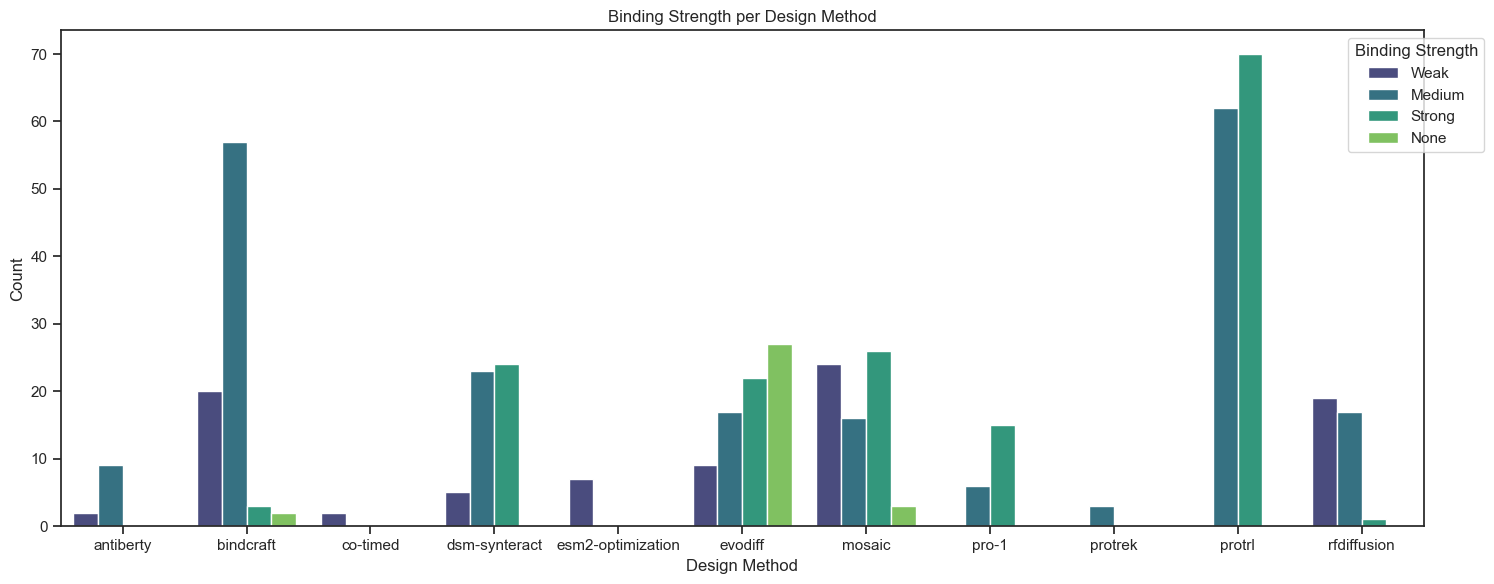

In [19]:
binding_strength_df = df_binders[df_binders["metric"] == "binding_strength"].copy()

binding_strength_df["values"] = pd.Categorical(binding_strength_df["values"], categories=["Weak", "Medium", "Strong", "None"], ordered=True)

plt.figure(figsize=(15, 6))
sns.countplot(data=binding_strength_df, x="designMethod", hue="values", palette="viridis", order=binding_strength_df["designMethod"].unique())

plt.xlabel("Design Method")
plt.ylabel("Count")
plt.title("Binding Strength per Design Method")
plt.legend(title="Binding Strength", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


This actually also shows which design methods have mixed results on whether or not the generated binder actually binds: bindcraft, evodiff and mosaic (seen as "None" here). 

**I want to now make some scatter plots comparing two metrics and colored by design method.**

In [20]:
subset = df_copy[df_copy["metric"].isin(relevant_metrics)].copy()

subset_pivot = subset.pivot_table(index=["id", "designMethod"], columns="metric", values="values", aggfunc="first").reset_index()
print(subset_pivot["designMethod"].unique())

### I'll also make a pivot table but with binders only using df_binders.
subset_binders = df_binders[df_binders["metric"].isin(relevant_metrics)].copy()
subset_binders_pivot = subset_binders.pivot_table(index=["id", "designMethod"], columns="metric", values="values", aggfunc="first").reset_index()
print(subset_binders_pivot["designMethod"].unique())
subset_binders_pivot


['bindcraft' 'co-timed' 'pro-1' 'mosaic' 'protrl' 'rfdiffusion' 'evodiff'
 'esm2-optimization' 'dsm-synteract' 'protrek' 'antiberty' 'llama-31-405b'
 'blosum62']
['pro-1' 'protrl' 'rfdiffusion' 'bindcraft' 'evodiff' 'mosaic'
 'dsm-synteract' 'protrek' 'antiberty' 'co-timed' 'esm2-optimization']


metric,id,designMethod,binding,binding_strength,esmfold_plddt,expressed,proteinmpnn_score,rmsdafdb50,rmsdcath50,rmsdpdb100,seqidentityafdb50,seqidentitycath50,seqidentitypdb100,tm-scoreafdb50,tm-scorecath50,tm-scorepdb100
0,amber-goat-onyx,pro-1,True,Medium,86.857394,True,1.6705,0.64,1.91,0.43,93.1,53,95.4,0.98284,0.81092,0.98289
1,amber-heron-pearl,protrl,True,Medium,83.584268,True,2.0359,0.53,2.67,2.8,80.9,59.5,59.5,0.93478,0.33955,0.32811
2,amber-heron-plume,rfdiffusion,True,Weak,88.11323,True,1.2079,1.6,2.96,2.57,18.8,15.2,24.4,0.81412,0.39452,0.61512
3,azure-bear-oak,rfdiffusion,True,Medium,85.961059,True,1.2943,1.27,2.23,3.9,19.2,23.4,22.2,0.87469,0.63756,0.32883
4,azure-crane-birch,protrl,True,Strong,80.969082,True,1.8267,0.84,2.73,2.68,64.8,67.5,68.4,0.8733,0.31364,0.30097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,wild-owl-crystal,bindcraft,True,Medium,76.281149,True,1.4146,4.74,4.71,4.49,16.6,11,18.3,0.45447,0.32495,0.46803
186,wild-quail-fern,bindcraft,True,Medium,79.776814,True,1.2433,2.91,3.73,3,14.7,10.9,18.1,0.59561,0.38524,0.53397
187,young-bear-cypress,mosaic,True,Medium,86.957133,True,1.3485,2.85,0.3,2.76,20.8,18.4,16.1,0.60789,0.15848,0.63793
188,young-otter-lotus,protrl,True,Medium,83.076295,True,1.8183,0.59,2.56,2.72,71.4,62.8,63.8,0.89599,0.32743,0.35084


**With the following code, we can create new plots by simply changing the y, x and hue values to our desired outcomes, to get a multi dimensional scatter plot with a specific metric as our colour hue.**

**This can also be modified to include other metrics than the ones shown in above data frame by changing the "relevant_metrics" variable which is defined further up.**

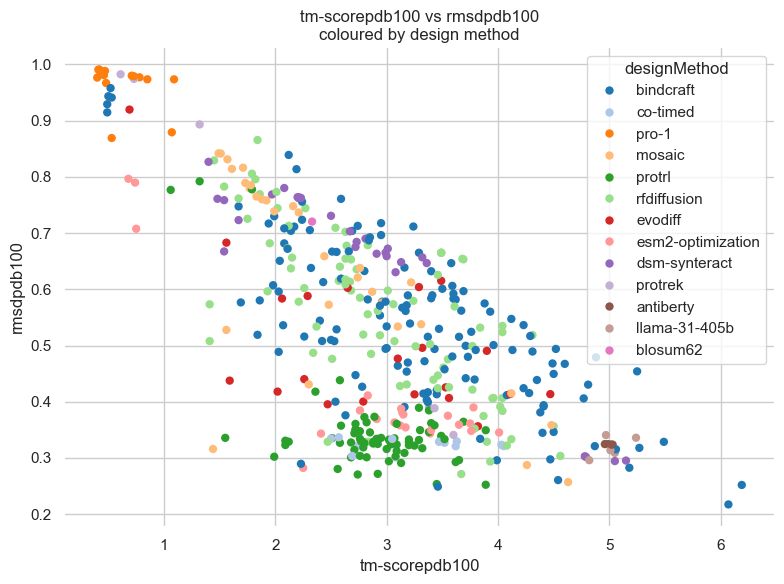

In [21]:
sns.set_theme(style="whitegrid")
f, ax = plt.subplots(figsize=(8, 6))
sns.despine(f, left=True, bottom=True)
sns.scatterplot(data=subset_pivot, y="tm-scorepdb100", x="rmsdpdb100", hue="designMethod", palette="tab20", sizes=(1, 8), linewidth=0, ax=ax)

plt.title("tm-scorepdb100 vs rmsdpdb100\ncoloured by design method")
plt.xlabel("tm-scorepdb100")
plt.ylabel("rmsdpdb100")
plt.tight_layout()
# plt.savefig("plots_no_designM/esmfold_vs_proteinmpnn_no_designM.png")
plt.show() 

In [22]:
### If we want to use the Kd value we first need to convert it from M to µM for easier use.
# subset_pivot["kd_µM"] = subset_pivot["kd"].apply(lambda x: x *1e6 if pd.notnull(x) else np.nan)

# subset_binders_pivot["kd_µM"] = subset_binders_pivot["kd"].apply(lambda x: x *1e6 if pd.notnull(x) else np.nan)

**This is the above scatterplot but for binders only**

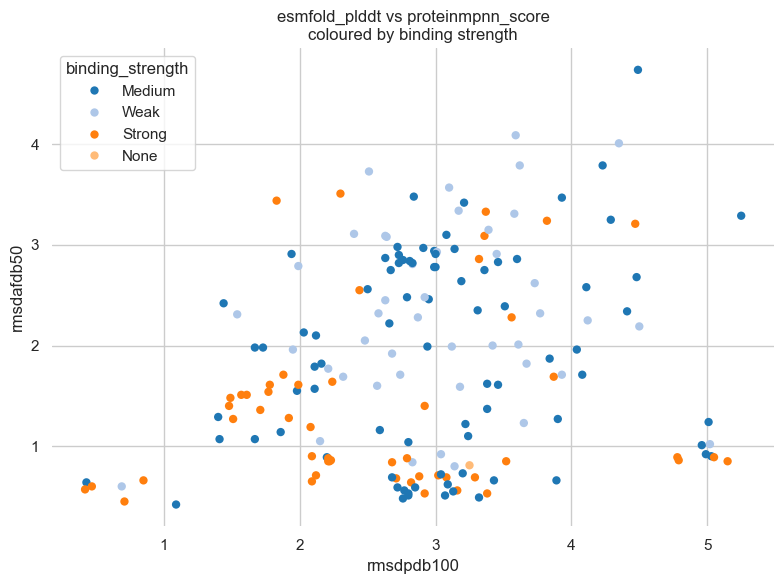

In [23]:
sns.set_theme(style="whitegrid")
f, ax = plt.subplots(figsize=(8, 6))
sns.despine(f, left=True, bottom=True)
sns.scatterplot(data=subset_binders_pivot, y="rmsdafdb50", x="rmsdpdb100", hue="binding_strength", palette="tab20", sizes=(1, 8), linewidth=0, ax=ax)

plt.title("esmfold_plddt vs proteinmpnn_score\ncoloured by binding strength")
plt.xlabel("rmsdpdb100")
plt.ylabel("rmsdafdb50")
plt.tight_layout()
# plt.savefig("plots_no_designM/esmfold_vs_proteinmpnn_no_designM.png")
plt.show()

In [24]:
### This step is repeatable for each design method, we just need to change out the method variable. First make a copy of the original pivot data frame, and make it equal to the desired design method.
# method = "bindcraft"
# df_method = subset_pivot[subset_pivot["designMethod"] == method].copy()

# ### Next we create variables for the two metrics we want to compare.
# x_metric = df_method["proteinmpnn_score"].tolist()
# y_metric = df_method["esmfold_plddt"].tolist()

# corr, _ = pearsonr(x_metric, y_metric)
# print("Pearsons correlation: %.3f" % corr)


**Next step is to calculate the Pearsons coefficient for different metric scores for each design method.**

**I will now try to automate it for each design method and each metric.**

**OBS: Changed to binders only! To look at both binders + non-binders simply change all instances of "subset_binders_pivot" to "subset_pivot".**

In [25]:
### I need to define columns to exclude due to them not being numeric and the numeric columns needs to be turned into floats instead of objects so we can iterate over all of them.

exclude_cols = ["id", "designMethod", "binding", "binding_strength", "expressed"]

for col in subset_binders_pivot.columns:
    if subset_binders_pivot[col].dtype == "object":
        try:
            subset_binders_pivot[col] = pd.to_numeric(subset_binders_pivot[col], errors='raise')
        except Exception:
            pass

numeric_cols = [col for col in subset_binders_pivot.columns if col not in exclude_cols and np.issubdtype(subset_binders_pivot[col].dtype, np.number)]

print("Column dtypes:")
print(subset_binders_pivot.dtypes)
print("Numeric metric columns:", numeric_cols)

### Now the real iteration loop will be created to compute all the correlations

results = []

for method in subset_binders_pivot["designMethod"].dropna().unique():
    df_method = subset_binders_pivot[subset_binders_pivot["designMethod"] == method].copy()

    for m1, m2 in combinations(numeric_cols, 2):
        valid = df_method[[m1, m2]].dropna()
        if len(valid) > 2:
            corr, pval = pearsonr(valid[m1], valid[m2])
        else:
            corr, pval = np.nan, np.nan
        
        results.append({"designMethod": method, "metric_1": m1, "metric_2": m2, "pearson_r": corr, "p_value": pval, "n": len(valid)})

corr_df = pd.DataFrame(results)
# corr_df.to_csv("binder_correlation_results.csv", index=False)

Column dtypes:
metric
id                    object
designMethod          object
binding                 bool
binding_strength      object
esmfold_plddt        float64
expressed               bool
proteinmpnn_score    float64
rmsdafdb50           float64
rmsdcath50           float64
rmsdpdb100           float64
seqidentityafdb50    float64
seqidentitycath50    float64
seqidentitypdb100    float64
tm-scoreafdb50       float64
tm-scorecath50       float64
tm-scorepdb100       float64
dtype: object
Numeric metric columns: ['esmfold_plddt', 'proteinmpnn_score', 'rmsdafdb50', 'rmsdcath50', 'rmsdpdb100', 'seqidentityafdb50', 'seqidentitycath50', 'seqidentitypdb100', 'tm-scoreafdb50', 'tm-scorecath50', 'tm-scorepdb100']
